In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='ticks')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import *

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# 자연어처리
import string
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from tqdm.auto import tqdm
from collections import Counter
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
np.set_printoptions(linewidth=200)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [17]:
import os
from google.colab import drive
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/10Days_Pytorch')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
cuda


#### Define Functions

In [18]:
# dataloader
def make_DataSet(x_train, x_val, y_train, y_val, batch_size=32):
  x_train_tensor = torch.tensor(x_train, dtype=torch.long)
  y_train_tensor = torch.tensor(y_train, dtype=torch.long)
  x_val_tensor = torch.tensor(x_val, dtype=torch.long)
  y_val_tensor = torch.tensor(y_val, dtype=torch.long)

  train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
  train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
  return train_loader, x_val_tensor, y_val_tensor

# training
def train(dataloader, model, loss_fn, optimizer, device):
    size = len(dataloader.dataset) # 전체 데이터 세트의 크기
    num_batches = len(dataloader) # 배치 크기
    tr_loss = 0

    model.train() # 학습 모드로 설정
    for x, y in dataloader: # 배치 단위로 로딩
        x, y = x.to(device), y.to(device) # 디바이스 지정

        # Feed Forward(오차 순전파)
        pred = model(x)
        loss = loss_fn(pred, y)
        tr_loss += loss

        # Backpropagation(오차 역전파)
        loss.backward() # 역전파를 통해 각 파라미터에 대한 오차의 기울기 계산
        optimizer.step() # 옵티마이저가 모델의 파라미터를 업데이트
        optimizer.zero_grad() # 옵티마이저의 기울기값 초기화.

    tr_loss /= num_batches # 모든 배치의 오차 평균
    return tr_loss.item()

# eval
def evaluate(x_val_tensor, y_val_tensor, model, loss_fn, device):
    model.eval() # 모델을 평가 모드로 설정

    with torch.no_grad(): # 평가 과정에서 기울기를 계산하지 않도록 설정
        x, y = x_val_tensor.to(device), y_val_tensor.to(device)
        pred = model(x)
        eval_loss = loss_fn(pred, y).item() # 예측값 pred와 목푯값 y 사이의 오차 계산

    return eval_loss, pred

# learning curve
def dl_learning_curve(tr_loss_list, val_loss_list):
    epochs = list(range(1, len(tr_loss_list)+1)) # 에포크 수 계산
    plt.plot(epochs, tr_loss_list, label='train_err', marker = '.') # 학습 오차 그래프
    plt.plot(epochs, val_loss_list, label='val_err', marker = '.') # 검증 오차 그래프
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid()
    plt.show()

#### Data loading

(20000, 2)


,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


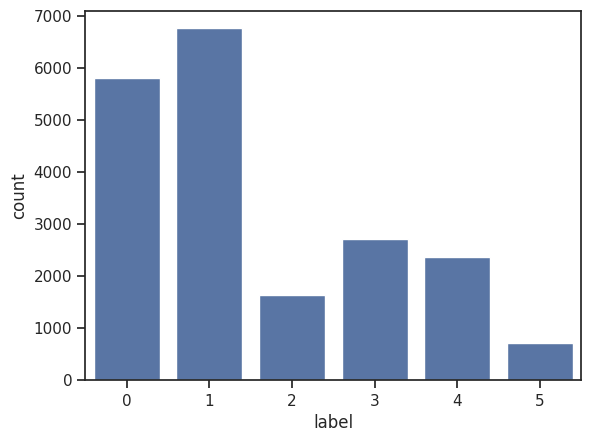

In [19]:
data = pd.read_csv('data/emotions.csv')
print(data.shape)
display(data.head())

# labels : 0 Sad, 1 Joy, 2 Love, 3 Anger, 4 Fear, 5 Surprise
sns.countplot(data=data, x = 'label')
plt.show()

#### 데이터 전처리

In [20]:
# 1)tokenize
# 불필요한 단어(Stopwords & 구두점) 집합 준비
stop_words = set(stopwords.words("english"))
punctuations = set(string.punctuation)

# 전처리 함수
def preprocess_text(text):
    tokens = word_tokenize(text.lower())
    tokens = [word for word in tokens if word not in stop_words and word not in punctuations]
    return tokens

data["tokens"] = data["text"].apply(preprocess_text)
data.head()

,text,label,tokens
0,i didnt feel humiliated,0,"[didnt, feel, humiliated]"
1,i can go from feeling so hopeless to so damned...,0,"[go, feeling, hopeless, damned, hopeful, aroun..."
2,im grabbing a minute to post i feel greedy wrong,3,"[im, grabbing, minute, post, feel, greedy, wrong]"
3,i am ever feeling nostalgic about the fireplac...,2,"[ever, feeling, nostalgic, fireplace, know, st..."
4,i am feeling grouchy,3,"[feeling, grouchy]"


In [21]:
# 2) vocab
all_words = [word for tokens in data["tokens"] for word in tokens]
word_counts = Counter(all_words)
vocab = {word: idx + 1 for idx, (word, _) in enumerate(word_counts.most_common())}
vocab[""] = 0
vocab[""] = len(vocab)
print(f"어휘 집합 크기: {len(vocab)}")

어휘 집합 크기: 16946


In [22]:
# 3) 정수 인덱스화
def text_to_sequence(tokens):
    return [vocab.get(word, vocab[""]) for word in tokens]
data["sequences"] = data["tokens"].apply(text_to_sequence)
data[["text", "tokens", "sequences"]].head()

,text,tokens,sequences
0,i didnt feel humiliated,"[didnt, feel, humiliated]","[50, 1, 510]"
1,i can go from feeling so hopeless to so damned...,"[go, feeling, hopeless, damned, hopeful, aroun...","[31, 2, 408, 2987, 431, 44, 54, 1565, 1252]"
2,im grabbing a minute to post i feel greedy wrong,"[im, grabbing, minute, post, feel, greedy, wrong]","[4, 2988, 1100, 183, 1, 381, 308]"
3,i am ever feeling nostalgic about the fireplac...,"[ever, feeling, nostalgic, fireplace, know, st...","[78, 2, 561, 4628, 6, 13, 3363]"
4,i am feeling grouchy,"[feeling, grouchy]","[2, 918]"


In [23]:
# 4) padding
data["len"] = data["tokens"].apply(len)
data.head()

,text,label,tokens,sequences,len
0,i didnt feel humiliated,0,"[didnt, feel, humiliated]","[50, 1, 510]",3
1,i can go from feeling so hopeless to so damned...,0,"[go, feeling, hopeless, damned, hopeful, aroun...","[31, 2, 408, 2987, 431, 44, 54, 1565, 1252]",9
2,im grabbing a minute to post i feel greedy wrong,3,"[im, grabbing, minute, post, feel, greedy, wrong]","[4, 2988, 1100, 183, 1, 381, 308]",7
3,i am ever feeling nostalgic about the fireplac...,2,"[ever, feeling, nostalgic, fireplace, know, st...","[78, 2, 561, 4628, 6, 13, 3363]",7
4,i am feeling grouchy,3,"[feeling, grouchy]","[2, 918]",2


95% 지점 20.0


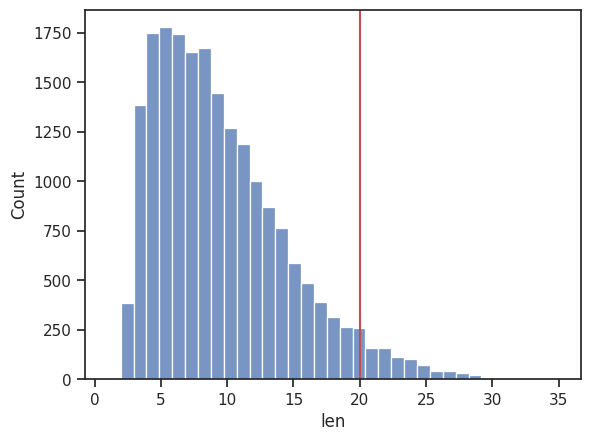

In [24]:
p95 = np.percentile(data['len'], 95)
print('95% 지점', p95)
sns.histplot(x = 'len', data = data, bins = 35)
plt.axvline(p95, color = 'r')
plt.show()

In [25]:
from keras.utils import pad_sequences
max_len = 20
sequences = pad_sequences(data["sequences"],
                            maxlen=max_len,
                            padding='post',
                            truncating='post',
                            value=vocab[""])

In [26]:
print(sequences[:10])

[[   50     1   510 16946 16946 16946 16946 16946 16946 16946 16946 16946 16946 16946 16946 16946 16946 16946 16946 16946]
 [   31     2   408  2987   431    44    54  1565  1252 16946 16946 16946 16946 16946 16946 16946 16946 16946 16946 16946]
 [    4  2988  1100   183     1   381   308 16946 16946 16946 16946 16946 16946 16946 16946 16946 16946 16946 16946 16946]
 [   78     2   561  4628     6    13  3363 16946 16946 16946 16946 16946 16946 16946 16946 16946 16946 16946 16946 16946]
 [    2   918 16946 16946 16946 16946 16946 16946 16946 16946 16946 16946 16946 16946 16946 16946 16946 16946 16946 16946]
 [   16     2     8   454   207   218    61 16946 16946 16946 16946 16946 16946 16946 16946 16946 16946 16946 16946 16946]
 [   16   233  8278    98  8279   748    16  2698  1394    64  1725    38     1     3   298 16946 16946 16946 16946 16946]
 [    1   342    18  1814   696    91   168   257 16946 16946 16946 16946 16946 16946 16946 16946 16946 16946 16946 16946]
 [ 5826   122   

In [27]:
# x, y
x = np.array(sequences)
y = np.array(data["label"])
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size = 0.2)
train_loader, x_val_ts, y_val_ts = make_DataSet(x_train, x_val, y_train, y_val, 32)

#### Modeling

In [28]:
# model
class SimpleLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, output_size):
        super(SimpleLSTMClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    def forward(self, x):
        x = self.embedding(x)
        _, (hidden, _) = self.lstm(x)
        out = self.fc(hidden[-1])
        return out

vocab_size = x_train.max().item() + 1
embedding_dim = 100
hidden_size = 128
output_size = 6
learning_rate = 0.001

model = SimpleLSTMClassifier(vocab_size, embedding_dim, hidden_size, output_size).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

Epoch 1, train loss : 1.585512, val loss : 1.567218
Epoch 2, train loss : 1.544022, val loss : 1.319301
Epoch 3, train loss : 0.856981, val loss : 0.612610
Epoch 4, train loss : 0.353079, val loss : 0.379950
Epoch 5, train loss : 0.174541, val loss : 0.365694
Epoch 6, train loss : 0.107501, val loss : 0.369640
Epoch 7, train loss : 0.074669, val loss : 0.343484
Epoch 8, train loss : 0.051666, val loss : 0.401033
Epoch 9, train loss : 0.046132, val loss : 0.407450
Epoch 10, train loss : 0.035552, val loss : 0.439442


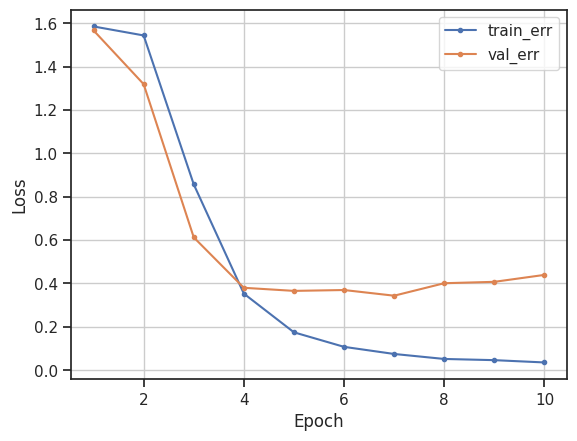

In [29]:
# training
epochs = 10
tr_loss_list, val_loss_list = [], []
for t in range(epochs):
    tr_loss = train(train_loader, model, loss_fn, optimizer, device)
    val_loss, _ = evaluate(x_val_ts, y_val_ts, model, loss_fn, device)
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)
    print(f"Epoch {t+1}, train loss : {tr_loss:4f}, val loss : {val_loss:4f}")

dl_learning_curve(tr_loss_list, val_loss_list)

<class 'torch.Tensor'>


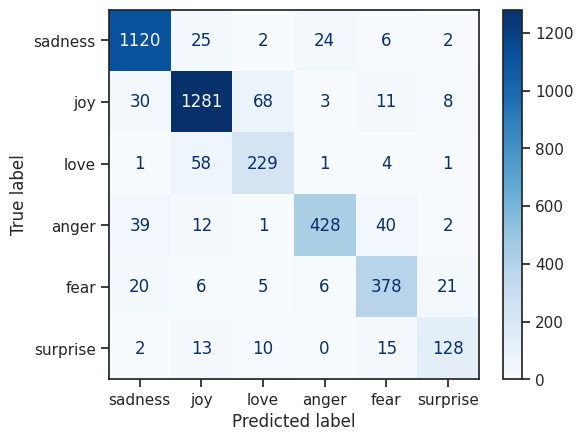

----------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

     sadness       0.92      0.95      0.94      1179
         joy       0.92      0.91      0.92      1401
        love       0.73      0.78      0.75       294
       anger       0.93      0.82      0.87       522
        fear       0.83      0.87      0.85       436
    surprise       0.79      0.76      0.78       168

    accuracy                           0.89      4000
   macro avg       0.85      0.85      0.85      4000
weighted avg       0.89      0.89      0.89      4000



In [30]:
# eval
_, pred = evaluate(x_val_ts, y_val_ts, model, loss_fn, device)
print(type(pred))
pred = pred.softmax(dim = 1)
pred = np.argmax(pred.cpu().numpy(), axis = 1)

# confusion matrix 시각화
label_list = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
cm = confusion_matrix(y_val_ts.cpu().numpy(), pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_list)
disp.plot(cmap="Blues")
plt.show()
print('-'*100)

# classification_report
print(classification_report(y_val_ts.cpu().numpy(), pred, target_names=label_list))